In [5]:
# Cell 1: paths and imports

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sampling rate: the UofT ECG Database guide states fs = 200 Hz
FS = 200

# Step 2 requirement: keep at least 10 seconds of ECG, so the minimum length is 200 * 10 = 2000 samples
MIN_DURATION_SECONDS = 10
MIN_SIGNAL_LENGTH_SAMPLES = FS * MIN_DURATION_SECONDS

# Step 3 later performs 5-second non-overlapping segmentation, so estimate segment counts here
SEGMENT_DURATION_SECONDS = 5
SEGMENT_LENGTH_SAMPLES = FS * SEGMENT_DURATION_SECONDS

# Project data are stored in F:\ECG.
# Make the notebook portable across local paths by resolving the F:\ECG project root.
PROJECT_ROOT = Path(r'F:\ECG')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

METADATA_CSV_PATH = RAW_DIR / 'ecguoftdb.csv'
SIGNALS_RAW_PKL_PATH = RAW_DIR / 'signals_raw.pkl'

METADATA_ALL_CLEAN_CSV_PATH = PROCESSED_DIR / 'metadata_all_clean.csv'
SIGNALS_ALL_CLEAN_PKL_PATH = PROCESSED_DIR / 'signals_all_clean.pkl'

METADATA_SIT_CLEAN_CSV_PATH = PROCESSED_DIR / 'metadata_sit_clean.csv'
SIGNALS_SIT_CLEAN_PKL_PATH = PROCESSED_DIR / 'signals_sit_clean.pkl'

print('Project root:', PROJECT_ROOT)
print('Raw metadata CSV:', METADATA_CSV_PATH)
print('Raw signal PKL:', SIGNALS_RAW_PKL_PATH)
print('Processed output folder:', PROCESSED_DIR)


Project root: F:\ECG
Raw metadata CSV: F:\ECG\data\raw\ecguoftdb.csv
Raw signal PKL: F:\ECG\data\raw\signals_raw.pkl
Processed output folder: F:\ECG\data\processed


In [7]:
# Cell 2: Read CSV and PKL

# Load metadata CSV and raw ECG signals.
metadata_raw = pd.read_csv(METADATA_CSV_PATH)

# record_number links CSV rows to PKL entries; keep it as int when possible.
metadata_raw['record_number'] = metadata_raw['record_number'].astype(int)

# Raw ECG signals are stored as signals_raw[record_number] = ECG signal.
with open(SIGNALS_RAW_PKL_PATH, 'rb') as f:
    signals_raw = pickle.load(f)

# PKL keys are integers and should match CSV record_number values.
signals_raw = {int(record_number): signal for record_number, signal in signals_raw.items()}

print('metadata_raw shape:', metadata_raw.shape)
print('signals_raw count:', len(signals_raw))
display(metadata_raw.head())


metadata_raw shape: (1627, 8)
signals_raw count: 1627


,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path
0,1,1,1,1,sit,24001,120.005,"signals[0,0][week=0][condition=0]"
1,2,2,1,1,sit,24001,120.005,"signals[0,1][week=0][condition=0]"
2,3,3,1,1,sit,24001,120.005,"signals[0,2][week=0][condition=0]"
3,4,4,1,1,sit,24001,120.005,"signals[0,3][week=0][condition=0]"
4,5,5,1,1,sit,24001,120.005,"signals[0,4][week=0][condition=0]"


In [9]:
# Cell 3: align CSV rows with PKL signals

csv_record_numbers = set(metadata_raw['record_number'].astype(int))
pkl_record_numbers = set(signals_raw.keys())

missing_in_pkl_record_numbers = sorted(csv_record_numbers - pkl_record_numbers)
extra_in_pkl_record_numbers = sorted(pkl_record_numbers - csv_record_numbers)

is_row_count_same = len(metadata_raw) == len(signals_raw)
sync_ok = (
    is_row_count_same
    and len(missing_in_pkl_record_numbers) == 0
    and len(extra_in_pkl_record_numbers) == 0
)

print('CSV row count:', len(metadata_raw))
print('PKL signal count:', len(signals_raw))
print('CSV and PKL row/signal counts match:', is_row_count_same)
print('record_number count present in CSV but missing in PKL:', len(missing_in_pkl_record_numbers))
print('record_number count present in PKL but missing in CSV:', len(extra_in_pkl_record_numbers))
print('CSV and PKL fully synchronized by record_number:', sync_ok)

if missing_in_pkl_record_numbers:
    print('first 20 record_numbers present in CSV but missing in PKL:', missing_in_pkl_record_numbers[:20])

if extra_in_pkl_record_numbers:
    print('first 20 record_numbers present in PKL but missing in CSV:', extra_in_pkl_record_numbers[:20])

# Check alignment before building cleaned data.
if not sync_ok:
    raise ValueError('CSV and PKL record_number values are not aligned.')


CSV row count: 1627
PKL signal count: 1627
CSV and PKL row/signal counts match: True
record_number count present in CSV but missing in PKL: 0
record_number count present in PKL but missing in CSV: 0
CSV and PKL fully synchronized by record_number: True


In [13]:
# Cell 4: Define the single-record ECG cleaning function

INVALID_REASONS = [
    'missing_in_pkl',
    'empty_signal',
    'cannot_convert_to_array',
    'not_1d_after_squeeze',
    'cannot_convert_to_float',
    'contains_nan',
    'contains_inf',
    'zero_std',
    'too_short_less_than_10s',
    'valid',
]


def clean_one_ecg_signal(record_number, signals_dict, fs=FS):
    """Clean one ECG signal.

    Returns two objects:
    1. info: cleaning result and length information for this record
    2. cleaned_signal: cleaned ECG array;returns None if invalid
    """

    def make_info(is_valid, invalid_reason, raw_length=np.nan, cleaned_length=np.nan):
        # If invalid, return an empty cleaned signal, NaN length, and zero expected segments.
        raw_duration = raw_length / fs if not pd.isna(raw_length) else np.nan
        cleaned_duration = cleaned_length / fs if not pd.isna(cleaned_length) else np.nan
        expected_5s_segments = int(cleaned_length // SEGMENT_LENGTH_SAMPLES) if is_valid else 0

        return {
            'is_valid': bool(is_valid),
            'invalid_reason': invalid_reason,
            'raw_signal_length_samples': raw_length,
            'raw_duration_seconds': raw_duration,
            'cleaned_signal_length_samples': cleaned_length,
            'cleaned_duration_seconds': cleaned_duration,
            'expected_5s_segments': expected_5s_segments,
        }

    # 1. record_number must exist in the PKL
    if record_number not in signals_dict:
        return make_info(False, 'missing_in_pkl'), None

    signal = signals_dict[record_number]

    # 2. signal must not be empty
    if signal is None:
        return make_info(False, 'empty_signal'), None

    # 3. signal must be convertible to a NumPy array
    try:
        signal_array = np.asarray(signal)
    except Exception:
        return make_info(False, 'cannot_convert_to_array'), None

    # 4. check whether it is empty before removing extra dimensions
    if signal_array.size == 0:
        return make_info(False, 'empty_signal', raw_length=0), None

    # 5. must be one-dimensional after squeeze
    signal_array = np.squeeze(signal_array)
    raw_length = int(signal_array.size)

    if signal_array.ndim != 1:
        return make_info(False, 'not_1d_after_squeeze', raw_length=raw_length), None

    # 6. signal must be convertible to float
    try:
        signal_array = signal_array.astype(float)
    except (ValueError, TypeError, OverflowError):
        return make_info(False, 'cannot_convert_to_float', raw_length=raw_length), None

    # 7. signal must not contain NaN
    if np.isnan(signal_array).any():
        return make_info(False, 'contains_nan', raw_length=raw_length), None

    # 8. signal must not contain Inf
    if np.isinf(signal_array).any():
        return make_info(False, 'contains_inf', raw_length=raw_length), None

    # 9. signal standard deviation must not be zero
    signal_mean = signal_array.mean()
    signal_std = signal_array.std()

    if signal_std == 0:
        return make_info(False, 'zero_std', raw_length=raw_length), None

    # 10. signal length must be >= 2000 samples, i.e., at least 10 seconds
    if raw_length < MIN_SIGNAL_LENGTH_SAMPLES:
        return make_info(False, 'too_short_less_than_10s', raw_length=raw_length), None

    # 11. Step 2 currently does not apply bandpass filtering; it only performs mean-centering and z-score normalization
    cleaned_signal = signal_array - signal_mean
    cleaned_signal = cleaned_signal / signal_std

    cleaned_length = int(cleaned_signal.shape[0])

    return make_info(True, 'valid', raw_length=raw_length, cleaned_length=cleaned_length), cleaned_signal


In [15]:
# Cell 5: Run ECG cleaning for all records

cleaned_metadata_rows = []
signals_all_clean = {}

# Read metadata row by row and use record_number to find the corresponding ECG signal
for _, row in metadata_raw.iterrows():
    record_number = int(row['record_number'])

    clean_info, cleaned_signal = clean_one_ecg_signal(record_number, signals_raw)

    # Keep original metadata fields and add/update Step 2 cleaning fields
    new_row = row.to_dict()
    new_row.update(clean_info)
    cleaned_metadata_rows.append(new_row)

    # Save only valid ECG signals to the clean signal dictionary
    if clean_info['is_valid']:
        signals_all_clean[record_number] = cleaned_signal

metadata_checked = pd.DataFrame(cleaned_metadata_rows)

# Keep all-clean ECG signals
metadata_all_clean = metadata_checked[metadata_checked['is_valid']].copy()
metadata_all_clean = metadata_all_clean.sort_values('record_number').reset_index(drop=True)

# Save PKL entries whose record_number is present in metadata_all_clean
signals_all_clean = {
    int(record_number): signals_all_clean[int(record_number)]
    for record_number in metadata_all_clean['record_number']
}

print('total record count:', len(metadata_checked))
print('all valid record count:', len(metadata_all_clean))
print('all clean signal count:', len(signals_all_clean))
display(metadata_all_clean.head())


total record count: 1627
all valid record count: 1627
all clean signal count: 1627


,record_number,subject_id,week_number,condition_number,condition_name,signal_length_samples,duration_seconds,signal_index_path,is_valid,invalid_reason,raw_signal_length_samples,raw_duration_seconds,cleaned_signal_length_samples,cleaned_duration_seconds,expected_5s_segments
0,1,1,1,1,sit,24001,120.005,"signals[0,0][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
1,2,2,1,1,sit,24001,120.005,"signals[0,1][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
2,3,3,1,1,sit,24001,120.005,"signals[0,2][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
3,4,4,1,1,sit,24001,120.005,"signals[0,3][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24
4,5,5,1,1,sit,24001,120.005,"signals[0,4][week=0][condition=0]",True,valid,24001,120.005,24001,120.005,24


In [17]:
# Cell 6: save all-clean outputs

metadata_all_clean.to_csv(METADATA_ALL_CLEAN_CSV_PATH, index=False)

with open(SIGNALS_ALL_CLEAN_PKL_PATH, 'wb') as f:
    pickle.dump(signals_all_clean, f)

print('Saved:', METADATA_ALL_CLEAN_CSV_PATH)
print('Saved:', SIGNALS_ALL_CLEAN_PKL_PATH)


Saved: F:\ECG\data\processed\metadata_all_clean.csv
Saved: F:\ECG\data\processed\signals_all_clean.pkl


In [19]:
# Cell 7: save sit-only outputs

# Keep valid ECG signals where condition_name == 'sit'
sit_mask = metadata_all_clean['condition_name'].astype(str).str.strip().str.lower() == 'sit'
metadata_sit_clean = metadata_all_clean[sit_mask].copy().reset_index(drop=True)

sit_record_numbers = metadata_sit_clean['record_number'].astype(int).tolist()
signals_sit_clean = {record_number: signals_all_clean[record_number] for record_number in sit_record_numbers}

metadata_sit_clean.to_csv(METADATA_SIT_CLEAN_CSV_PATH, index=False)

with open(SIGNALS_SIT_CLEAN_PKL_PATH, 'wb') as f:
    pickle.dump(signals_sit_clean, f)

print('sit valid record count:', len(metadata_sit_clean))
print('sit clean signal count:', len(signals_sit_clean))
print('Saved:', METADATA_SIT_CLEAN_CSV_PATH)
print('Saved:', SIGNALS_SIT_CLEAN_PKL_PATH)


sit valid record count: 1288
sit clean signal count: 1288
Saved: F:\ECG\data\processed\metadata_sit_clean.csv
Saved: F:\ECG\data\processed\signals_sit_clean.pkl


In [21]:
# Cell 8: summary and validation

deleted_reason_counts = (
    metadata_checked.loc[~metadata_checked['is_valid'], 'invalid_reason']
    .value_counts()
    .reindex(INVALID_REASONS[:-1], fill_value=0)
)

all_clean_subject_count = metadata_all_clean['subject_id'].nunique()
sit_clean_subject_count = metadata_sit_clean['subject_id'].nunique()
sit_expected_5s_segments_total = int(metadata_sit_clean['expected_5s_segments'].sum())
sit_records_by_week = metadata_sit_clean['week_number'].value_counts().sort_index()

first_5_clean_shapes = []
for record_number in metadata_all_clean['record_number'].astype(int).head(5):
    first_5_clean_shapes.append((record_number, signals_all_clean[record_number].shape))

print('========== Step 2 Cleaning Summary ==========' )
print('raw metadata row count:', len(metadata_raw))
print('raw PKL signal count:', len(signals_raw))
print('CSV and PKL synchronized:', sync_ok)
print('all valid record count after cleaning:', len(metadata_all_clean))
print('sit valid record count after cleaning:', len(metadata_sit_clean))
print('\ndeleted record count grouped by invalid_reason:')
print(deleted_reason_counts.to_string())
print('\nsubject count retained in all-clean data:', all_clean_subject_count)
print('subject count retained in sit-clean data:', sit_clean_subject_count)
print('expected total number of 5-second segments from sit-clean data:', sit_expected_5s_segments_total)
print('\nsit clean record count per week:')
print(sit_records_by_week.to_string())
print('\nshape of the first five cleaned signals:')
for record_number, shape in first_5_clean_shapes:
    print(f'record_number={record_number}, shape={shape}')

# Validation: metadata and PKL should cover the same valid records
assert len(metadata_all_clean) == len(signals_all_clean)
assert len(metadata_sit_clean) == len(signals_sit_clean)
assert set(metadata_all_clean['record_number'].astype(int)) == set(signals_all_clean.keys())
assert set(metadata_sit_clean['record_number'].astype(int)) == set(signals_sit_clean.keys())

print('\nSaved clean metadata and clean signal PKL files.')


========== Step 2 Cleaning Summary ==========
raw metadata row count: 1627
raw PKL signal count: 1627
CSV and PKL synchronized: True
all valid record count after cleaning: 1627
sit valid record count after cleaning: 1288

deleted record count grouped by invalid_reason:
invalid_reason
missing_in_pkl             0
empty_signal               0
cannot_convert_to_array    0
not_1d_after_squeeze       0
cannot_convert_to_float    0
contains_nan               0
contains_inf               0
zero_std                   0
too_short_less_than_10s    0

subject count retained in all-clean data: 1019
subject count retained in sit-clean data: 1019
expected total number of 5-second segments from sit-clean data: 36103

sit clean record count per week:
week_number
1    1012
2      72
3      76
4      63
6      65

shape of the first five cleaned signals:
record_number=1, shape=(24001,)
record_number=2, shape=(24001,)
record_number=3, shape=(24001,)
record_number=4, shape=(24001,)
record_number=5, shape=

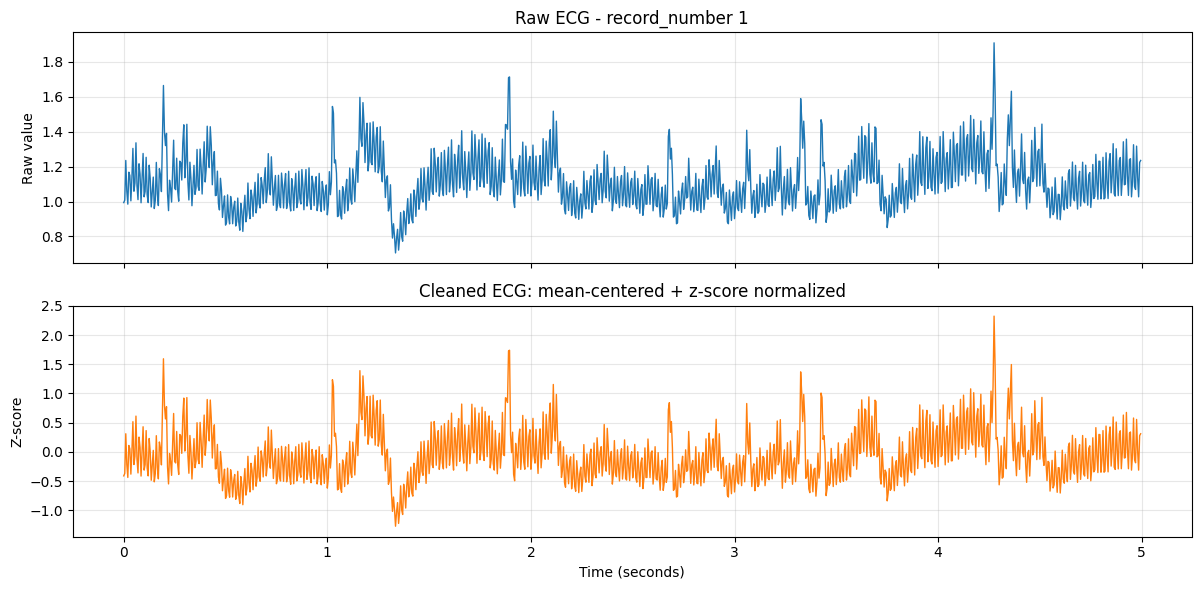

In [23]:
# Cell 9: Plot a comparison of the first 5 seconds before and after cleaning

if len(metadata_all_clean) == 0:
    raise ValueError('No valid ECG signals were found.')

# Choose the first valid ECG as an example
example_record_number = int(metadata_all_clean.iloc[0]['record_number'])

raw_example_signal = np.asarray(signals_raw[example_record_number]).squeeze().astype(float)
cleaned_example_signal = signals_all_clean[example_record_number]

# Sanity check 5-second segmentation. The expected count uses floor division by 5 seconds.
plot_length = min(SEGMENT_LENGTH_SAMPLES, len(raw_example_signal), len(cleaned_example_signal))
time_axis = np.arange(plot_length) / FS

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(time_axis, raw_example_signal[:plot_length], linewidth=1)
axes[0].set_title(f'Raw ECG - record_number {example_record_number}')
axes[0].set_ylabel('Raw value')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, cleaned_example_signal[:plot_length], linewidth=1, color='tab:orange')
axes[1].set_title('Cleaned ECG: mean-centered + z-score normalized')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Z-score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
